# 5 · Singularities

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rudip1/learn-manipulator-control/blob/main/2_notebooks/exercises/05_singularities.ipynb)

Theory: [`1_theory/05_singularities.md`](../../1_theory/05_singularities.md) · notation:
[`00_notation.md`](../../1_theory/00_notation.md)

In [1]:
# Install the module when it is not importable yet (Colab, fresh environment).
import importlib.util
if importlib.util.find_spec("manipulator_control") is None:
    %pip install -q git+https://github.com/Rudip1/learn-manipulator-control

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import manipulator_control as mc
from manipulator_control import plotting

plt.rcParams.update({"figure.dpi": 80, "axes.grid": True})
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(5)

## Recap

- With $J = \sum_i s_i u_i v_i^T$, the pseudoinverse applies gain $1/s_i$ along $u_i$; near a singularity
  ($s_m \to 0$) joint rates explode.
- Velocity ellipsoid with semi-axes $s_iu_i$ (eq. 5.1); manipulability $w = \sqrt{\det JJ^T} = \prod s_i$ (eq. 5.2);
  for the planar two-link arm $w = l_1l_2|\sin q_2|$ (eq. 5.3).
- Damped least squares minimises $\|J\dot q - v\|^2 + \lambda^2\|\dot q\|^2$: $J^\dagger_\lambda = J^T(JJ^T + \lambda^2I)^{-1}
  = \sum_i \frac{s_i}{s_i^2+\lambda^2}v_iu_i^T$ (eqs. 5.4–5.5), so $\|\dot q\| \le \|v\|/2\lambda$ (eq. 5.6).
- The price: convergence rate $k s_i^2/(s_i^2+\lambda^2)$ (eq. 5.7). Variable damping (eqs. 5.8–5.9) damps only near
  singularities.

## Ellipses and manipulability across the workspace

Colour every reachable point of the two-link arm (elbow-down solutions) by its manipulability. It depends only on
$q_2$, i.e. on the distance from the base: zero on both boundary circles, largest in between.

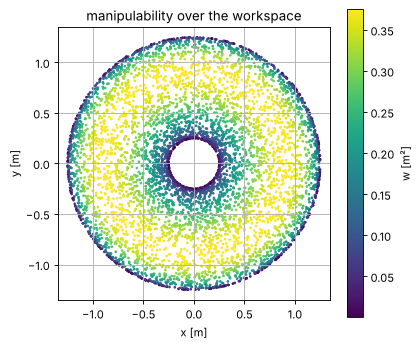

max w: 0.37499999120472194  closed form l1*l2 = 0.375


In [3]:
arm = mc.robots.planar([0.75, 0.5])
Q = rng.uniform([-np.pi, 0.0], [np.pi, np.pi], (6000, 2))
P = np.array([arm.end_effector(q)[:2, 3] for q in Q])
W = np.array([mc.manipulability(mc.geometric_jacobian(arm, q)[:2]) for q in Q])
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(P[:, 0], P[:, 1], c=W, s=2, cmap="viridis")
plt.colorbar(sc, label="w [m²]")
plotting.planar_axes(ax, limit=1.35, title="manipulability over the workspace")
plt.show()
print("max w:", W.max(), " closed form l1*l2 =", 0.75 * 0.5)

## The wrist singularity of the PUMA 560

The PUMA tracks a 15 cm straight line, at constant orientation, chosen so that $q_5$ must pass through zero. The
same reference is given to three controllers (the whole loop runs in C++, `simulate_pose_tracking`).

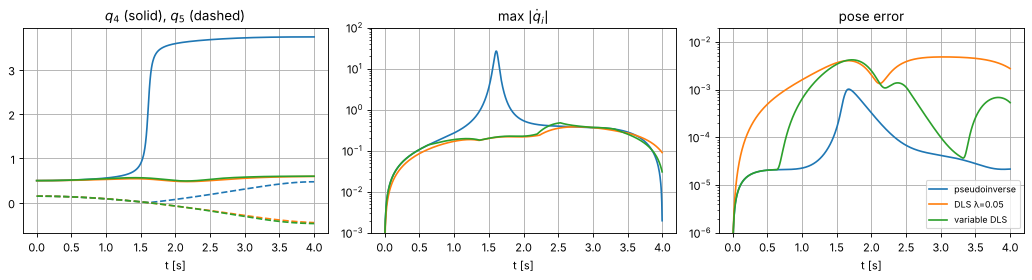

pseudoinverse  max|qdot| =  26.76 rad/s   max error = 1.0e-03   final error = 2.2e-05   q4 turned by +3.24 rad
DLS λ=0.05     max|qdot| =   0.38 rad/s   max error = 4.9e-03   final error = 2.8e-03   q4 turned by +0.10 rad
variable DLS   max|qdot| =   0.48 rad/s   max error = 4.2e-03   final error = 5.4e-04   q4 turned by +0.10 rad


In [4]:
puma = mc.robots.puma560()
qa = np.array([0.0, 0.6, -0.3, 0.5, 0.15, 0.0])
Ta = puma.end_effector(qa)
g = np.linalg.inv(mc.geometric_jacobian(puma, qa))[4, :3]   # dq5/dp for a pure translation
dp = -0.15 * g / np.linalg.norm(g)
T, dt = 4.0, 0.005
k = np.arange(int(T / dt) + 1)
s = 0.5 * (1 - np.cos(np.pi * k / k[-1])); sd = 0.5 * np.pi / T * np.sin(np.pi * k / k[-1])
poses, twists = [], np.zeros((k.size, 6))
for i in k:
    Td = Ta.copy(); Td[:3, 3] += s[i] * dp
    poses.append(Td); twists[i, :3] = sd[i] * dp

configs = {
    "pseudoinverse": mc.ResolvedRateConfig(gain=5.0, dt=dt),
    "DLS λ=0.05": mc.ResolvedRateConfig(method=mc.InverseMethod.DampedLeastSquares, damping=0.05, gain=5.0, dt=dt),
    "variable DLS": mc.ResolvedRateConfig(method=mc.InverseMethod.DampedLeastSquares, damping=0.05, gain=5.0, dt=dt,
                                          damping_schedule=mc.DampingSchedule.MinSingularValue, damping_threshold=0.05),
}
runs = {name: mc.simulate_pose_tracking(puma, qa, poses, twists, cfg) for name, cfg in configs.items()}

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for c, (name, tr) in enumerate(runs.items()):
    ax[0].plot(tr.t, tr.q[:, 3], color=f"C{c}", label=f"{name}: $q_4$")
    ax[0].plot(tr.t, tr.q[:, 4], color=f"C{c}", linestyle="--")
    ax[1].semilogy(tr.t[:-1], np.abs(tr.qdot[:-1]).max(axis=1), color=f"C{c}")
    ax[2].semilogy(tr.t, np.maximum(tr.error_norm, 1e-7), color=f"C{c}", label=name)
ax[0].set_title("$q_4$ (solid), $q_5$ (dashed)"); ax[1].set_title(r"max $|\dot q_i|$"); ax[1].set_ylim(1e-3, 1e2)
ax[2].set_title("pose error"); ax[2].set_ylim(1e-6, 2e-2); ax[2].legend(fontsize=8)
for a in ax: a.set_xlabel("t [s]")
plt.tight_layout(); plt.show()
for name, tr in runs.items():
    print(f"{name:14s} max|qdot| = {np.abs(tr.qdot).max():6.2f} rad/s   max error = {tr.error_norm.max():.1e}"
          f"   final error = {tr.error_norm[-1]:.1e}   q4 turned by {tr.q[-1, 3] - qa[3]:+.2f} rad")

## How the inverses treat the weak direction

Plot the gain each inverse applies along a singular direction, as a function of the singular value: $1/s$ for the
pseudoinverse, $s/(s^2+\lambda^2)$ for DLS (eq. 5.5). The DLS gain never exceeds $1/2\lambda$.

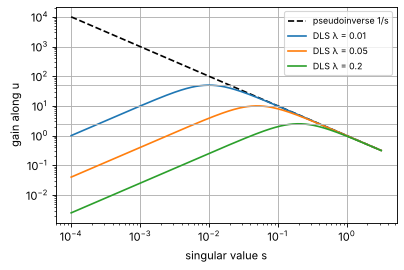

In [5]:
s_axis = np.logspace(-4, 0.5, 300)
plt.figure(figsize=(5.5, 3.5))
plt.loglog(s_axis, 1 / s_axis, "k--", label="pseudoinverse 1/s")
for lam in [0.01, 0.05, 0.2]:
    plt.loglog(s_axis, s_axis / (s_axis**2 + lam**2), label=f"DLS λ = {lam}")
    plt.axhline(1 / (2 * lam), color="0.7", linewidth=0.8)
plt.xlabel("singular value s"); plt.ylabel("gain along u"); plt.legend(fontsize=8); plt.show()

## ✏️ Exercises

### ✏️ 1. Manipulability of the two-link arm

Show that $\det J = l_1 l_2\sin q_2$ for the $2\times2$ position Jacobian of section 3.2, then write $w(q)$.

<!-- BEGIN SOLUTION -->
$\det J = (-l_1s_1 - l_2s_{12})\,l_2c_{12} + l_2s_{12}\,(l_1c_1 + l_2c_{12}) = l_1l_2(s_{12}c_1 - s_1c_{12}) = l_1l_2\sin q_2$.
For a square Jacobian $w = \sqrt{\det(JJ^T)} = |\det J|$.
<!-- END SOLUTION -->

In [6]:
l1, l2 = 0.75, 0.5
def w_2r(q):
    ### BEGIN SOLUTION
    return l1 * l2 * abs(np.sin(q[1]))
    ### END SOLUTION

In [7]:
for _ in range(20):
    q = rng.uniform(-np.pi, np.pi, 2)
    assert np.isclose(w_2r(q), mc.manipulability(mc.geometric_jacobian(arm, q)[:2]))
print("✓ w_2r")

✓ w_2r


### ✏️ 2. DLS through the SVD

Implement eq. (5.5) with `np.linalg.svd` (no matrix inverse).

In [8]:
def dls_svd(J, lam):
    ### BEGIN SOLUTION
    U, s, Vt = np.linalg.svd(J, full_matrices=False)
    return Vt.T @ np.diag(s / (s**2 + lam**2)) @ U.T
    ### END SOLUTION

In [9]:
for _ in range(10):
    J = rng.normal(size=(3, 6)); J[2] = J[0] + 1e-5 * J[2]
    assert np.allclose(dls_svd(J, 0.07), mc.dls_inverse(J, 0.07))
print("✓ dls_svd")

✓ dls_svd


### ✏️ 3. Choose λ for a joint-speed budget

A controller sends task velocities of at most $\|v\| = 0.3$ m/s and the joints may move at most 1.5 rad/s (in
norm). Using eq. (5.6), what is the smallest damping that guarantees the budget at *every* configuration? Check it
on random, nearly singular Jacobians.

In [10]:
v_max, qdot_max = 0.3, 1.5
### BEGIN SOLUTION
lam_min = v_max / (2 * qdot_max)
### END SOLUTION

In [11]:
worst = 0.0
for _ in range(2000):
    J = rng.normal(size=(2, 3)); J[1] = J[0] * rng.uniform(-1, 1) + rng.uniform(0, 0.3) * J[1]
    v = rng.normal(size=2); v *= v_max / np.linalg.norm(v)
    worst = max(worst, np.linalg.norm(mc.dls_inverse(J, lam_min) @ v))
assert worst <= qdot_max + 1e-9 and np.isclose(lam_min, 0.1)
print(f"✓ λ = {lam_min:.3f}, worst joint speed over 2000 Jacobians: {worst:.3f} rad/s")

✓ λ = 0.100, worst joint speed over 2000 Jacobians: 1.500 rad/s


### ✏️ 4. A variable damping schedule

Implement eq. (5.9): $\lambda^2 = (1 - (s_m/\varepsilon)^2)\lambda_{\max}^2$ below the threshold, zero above.

In [12]:
def damping_min_sv(J, lam_max, eps):
    ### BEGIN SOLUTION
    s_min = np.linalg.svd(J, compute_uv=False)[-1]
    return 0.0 if s_min >= eps else lam_max * np.sqrt(1 - (s_min / eps) ** 2)
    ### END SOLUTION

In [13]:
for q2 in np.linspace(-0.3, 0.3, 31):
    J = mc.geometric_jacobian(arm, np.array([0.4, q2]))[:2]
    assert np.isclose(damping_min_sv(J, 0.1, 0.08), mc.damping_factor(J, mc.DampingSchedule.MinSingularValue, 0.1, 0.08))
print("✓ damping_min_sv")

✓ damping_min_sv


## 🔨 Break it

### 🔨 1. Too much damping

Track a circle well inside the workspace (no singularity anywhere) with growing constant damping. The arm becomes
sluggish: the error grows with $\lambda$ even though nothing is singular (eq. 5.7).

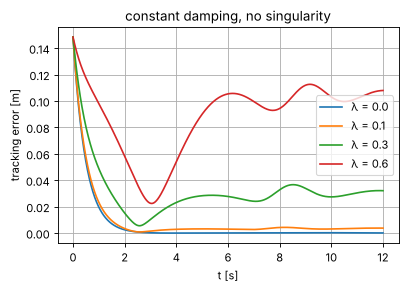

In [14]:
dt = 0.01
t = np.arange(0, 12 + dt / 2, dt)
pos = np.array([0.6, 0.4]) + 0.3 * np.column_stack([np.cos(0.5 * t), np.sin(0.5 * t)])
vel = 0.15 * np.column_stack([-np.sin(0.5 * t), np.cos(0.5 * t)])
q_c = np.array([-0.3, 1.6])
plt.figure(figsize=(5.5, 3.5))
for lam in [0.0, 0.1, 0.3, 0.6]:
    cfg = mc.ResolvedRateConfig(method=mc.InverseMethod.DampedLeastSquares, damping=lam, gain=2.0, dt=dt)
    tr = mc.simulate_position_tracking(arm, q_c, pos, vel, cfg)
    plt.plot(t, tr.error_norm, label=f"λ = {lam}")
plt.xlabel("t [s]"); plt.ylabel("tracking error [m]"); plt.legend(); plt.title("constant damping, no singularity")
plt.show()

### 🔨 2. A pseudoinverse with a tiny tolerance

Near the wrist singularity, $s_6$ is small but not zero, so the pseudoinverse still inverts it. With $k = 5$, one
control step from $q_5 = 10^{-3}$ asks for more than 10 rad/s to fix a 1 mm error along the lost direction; DLS asks
for less than a thousandth of that and simply leaves the error for later.

In [15]:
q = np.array([0.0, 0.6, -0.3, 0.5, 1e-3, 0.0])
J = mc.geometric_jacobian(puma, q)
u_lost = mc.manipulability_ellipsoid(J).axes[:, 5]
e = 1e-3 * u_lost
print("pseudoinverse:  |qdot| =", np.linalg.norm(mc.pseudoinverse(J) @ (5 * e)), "rad/s")
print("DLS λ = 0.05:   |qdot| =", np.linalg.norm(mc.dls_inverse(J, 0.05) @ (5 * e)), "rad/s")

pseudoinverse:  |qdot| = 11.404035332014157 rad/s
DLS λ = 0.05:   |qdot| = 0.0008768151662927544 rad/s


### 🔨 3. Conditioning depends on the length unit

For a full-pose task the Jacobian mixes metres and radians. Express lengths in millimetres (multiply the three
position rows by 1000). The manipulability of every configuration is multiplied by the same constant
($\det(SJJ^TS) = \det(S)^2\det(JJ^T)$), so comparisons of $w$ survive — but the condition number changes
configuration by configuration, and so does the ranking of "well-conditioned" poses.

In [16]:
samples = rng.uniform(-np.pi, np.pi, (300, 6))
S_mm = np.diag([1000, 1000, 1000, 1, 1, 1])
J_all = [mc.geometric_jacobian(puma, q) for q in samples]
w_ratio = [mc.manipulability(S_mm @ J) / mc.manipulability(J) for J in J_all[:5]]
kappa_m = np.array([mc.condition_number(J) for J in J_all])
kappa_mm = np.array([mc.condition_number(S_mm @ J) for J in J_all])
print("w(mm) / w(m) for five samples:", np.round(w_ratio, 1))
print("best-conditioned sample in metres:     ", int(np.argmin(kappa_m)), f"(kappa = {kappa_m.min():.1f})")
print("best-conditioned sample in millimetres:", int(np.argmin(kappa_mm)), f"(kappa = {kappa_mm.min():.1f})")
rank = lambda x: np.argsort(np.argsort(x))
print("rank correlation of the two kappa orderings:", np.corrcoef(rank(kappa_m), rank(kappa_mm))[0, 1].round(3))

w(mm) / w(m) for five samples: [1.e+09 1.e+09 1.e+09 1.e+09 1.e+09]
best-conditioned sample in metres:      59 (kappa = 6.9)
best-conditioned sample in millimetres: 232 (kappa = 450.3)


rank correlation of the two kappa orderings: 0.369


## What to remember

- Near a singularity the pseudoinverse divides by a small singular value: joint rates blow up and the
  configuration jumps (the wrist flip).
- $s_m$, $w = \prod s_i$ and $\kappa$ measure the distance to a singularity; with mixed units, $s_m$ and $\kappa$
  depend on the units chosen.
- DLS bounds the joint speed by $\|v\|/2\lambda$ at the price of slower convergence along weak directions.
- Damp only where needed: a continuous variable-damping schedule gives the pseudoinverse far from singularities.